# Assignment 2: BPNN Optimization and Hyperparameter Analysis

=== Result Table ===
              Experiment Hidden layers Activation Optimizer    LR  Epochs  Final train loss  Final val loss  Test accuracy
E6 Adam high LR 3 hidden   [32, 16, 8]       relu      Adam 0.020     100            0.0582          0.0654         0.9900
         E6 Adam high LR       [16, 8]       relu      Adam 0.020     100            0.0636          0.0645         0.9833
                 E5 Adam       [16, 8]       relu      Adam 0.010     100            0.2447          0.2067         0.9733
          E3 Deeper ReLU        [8, 8]       relu       SGD 0.010     100            0.6253          0.6178         0.8833
             E4 Momentum        [8, 8]       relu  Momentum 0.010     100            0.3352          0.2994         0.8633
          E6 Adam low LR       [16, 8]       relu      Adam 0.001     100            0.4560          0.4396         0.8567
         E2 More neurons           [8]    sigmoid       SGD 0.010     100            0.6639          0.6621         0.

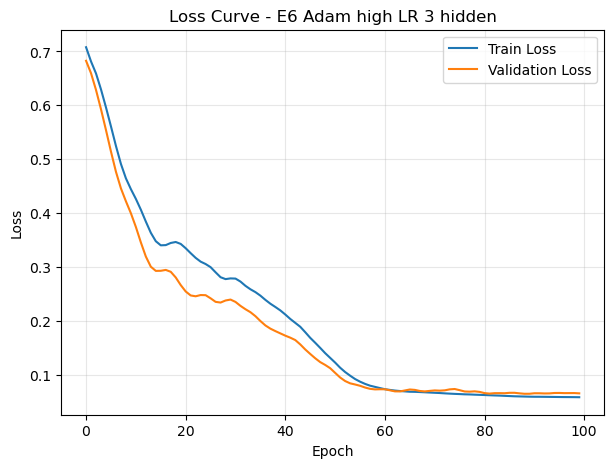

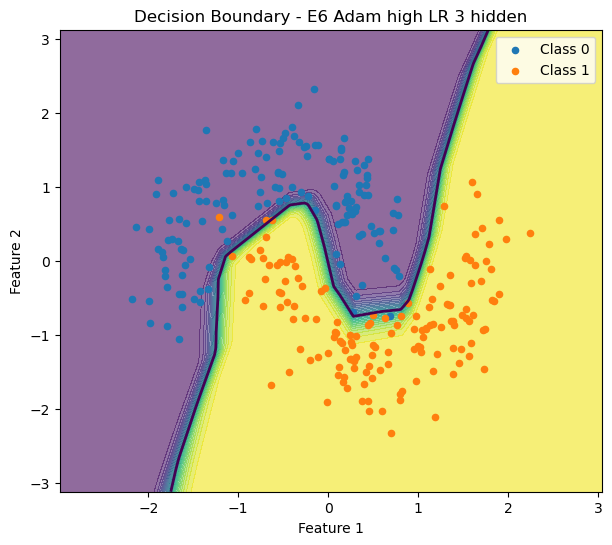


=== #2/8 Experiment ===
Experiment: E6 Adam high LR
Hidden layers: [16, 8]
Activation: relu
Optimizer: Adam
Learning rate: 0.02
Epochs: 100
Final train loss: 0.0636
Final val loss: 0.0645
Test accuracy: 0.9833


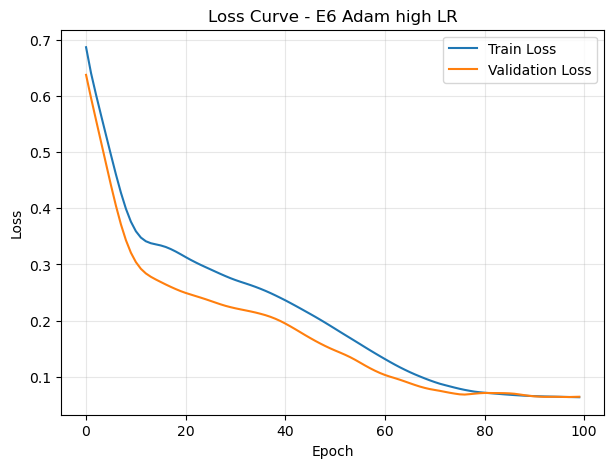

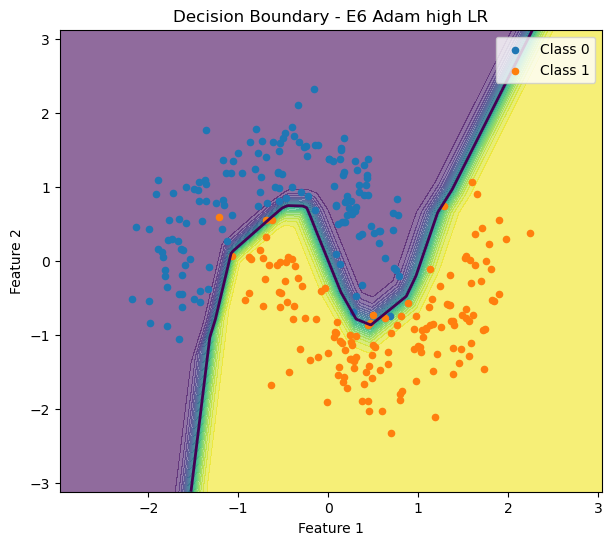


=== #3/8 Experiment ===
Experiment: E5 Adam
Hidden layers: [16, 8]
Activation: relu
Optimizer: Adam
Learning rate: 0.01
Epochs: 100
Final train loss: 0.2447
Final val loss: 0.2067
Test accuracy: 0.9733


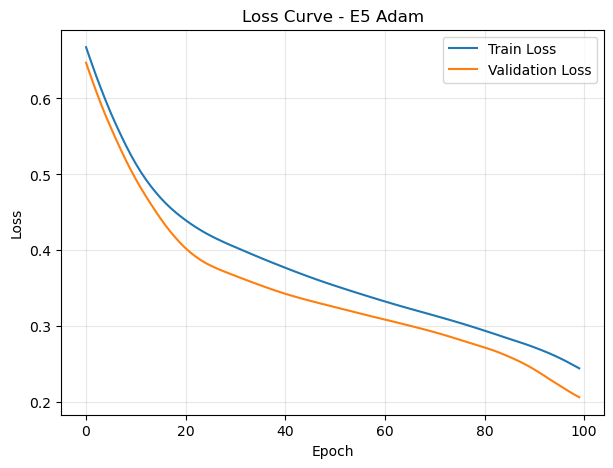

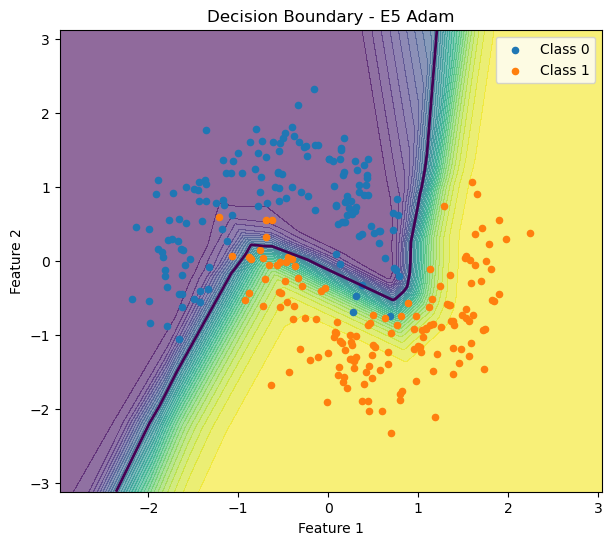


=== #4/8 Experiment ===
Experiment: E3 Deeper ReLU
Hidden layers: [8, 8]
Activation: relu
Optimizer: SGD
Learning rate: 0.01
Epochs: 100
Final train loss: 0.6253
Final val loss: 0.6178
Test accuracy: 0.8833


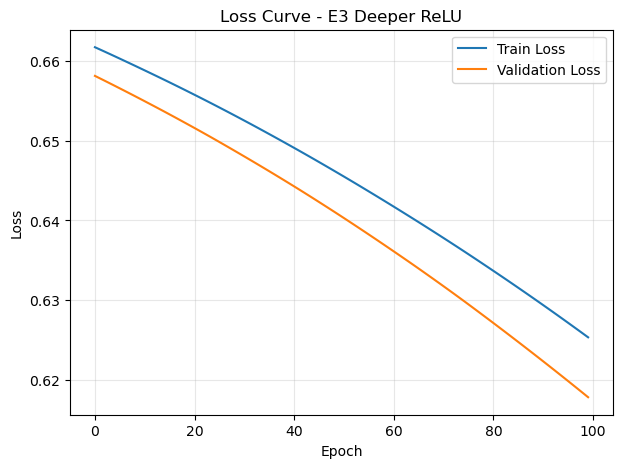

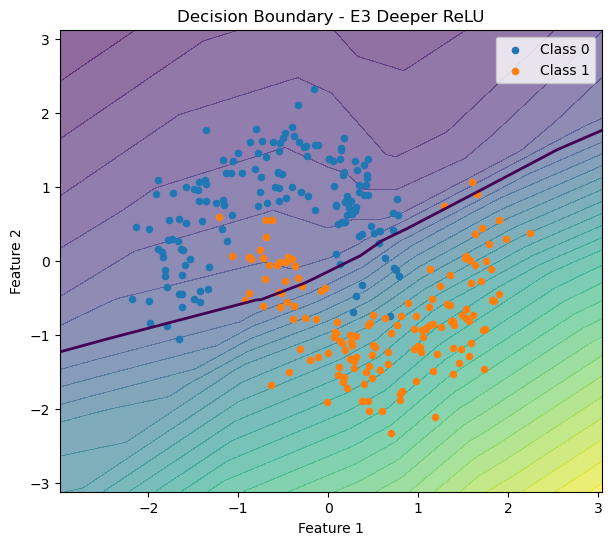


=== #5/8 Experiment ===
Experiment: E4 Momentum
Hidden layers: [8, 8]
Activation: relu
Optimizer: Momentum
Learning rate: 0.01
Epochs: 100
Final train loss: 0.3352
Final val loss: 0.2994
Test accuracy: 0.8633


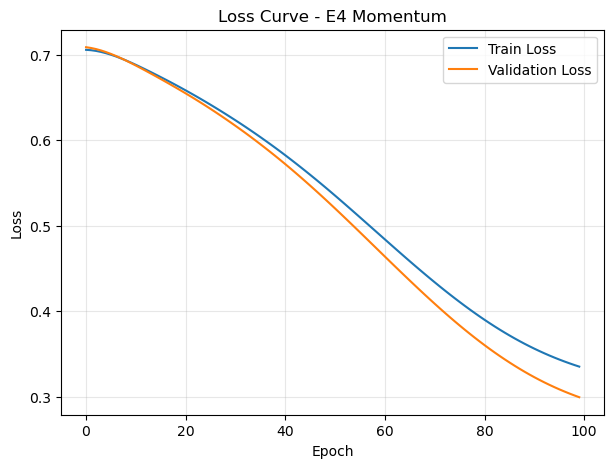

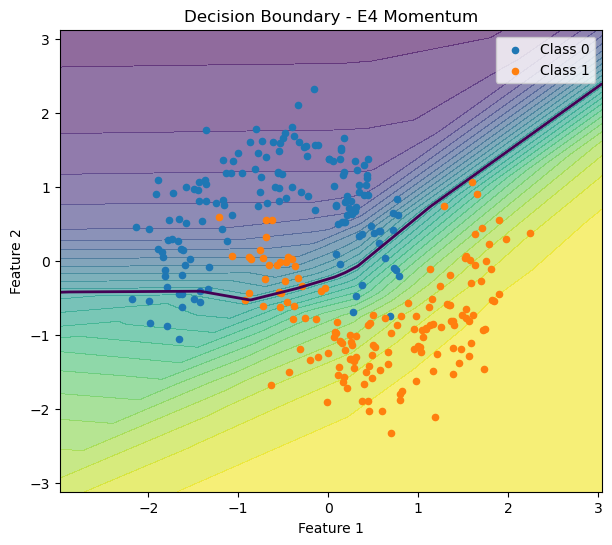


=== #6/8 Experiment ===
Experiment: E6 Adam low LR
Hidden layers: [16, 8]
Activation: relu
Optimizer: Adam
Learning rate: 0.001
Epochs: 100
Final train loss: 0.4560
Final val loss: 0.4396
Test accuracy: 0.8567


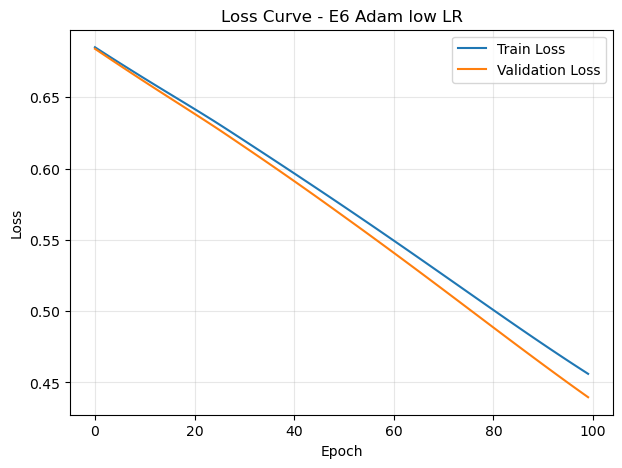

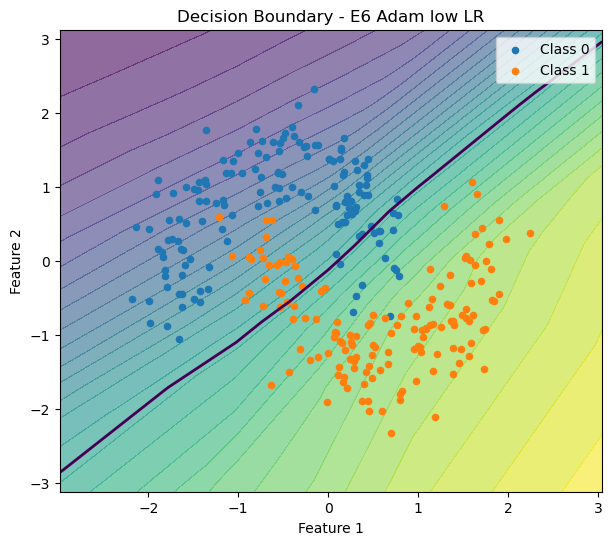


=== #7/8 Experiment ===
Experiment: E2 More neurons
Hidden layers: [8]
Activation: sigmoid
Optimizer: SGD
Learning rate: 0.01
Epochs: 100
Final train loss: 0.6639
Final val loss: 0.6621
Test accuracy: 0.7067


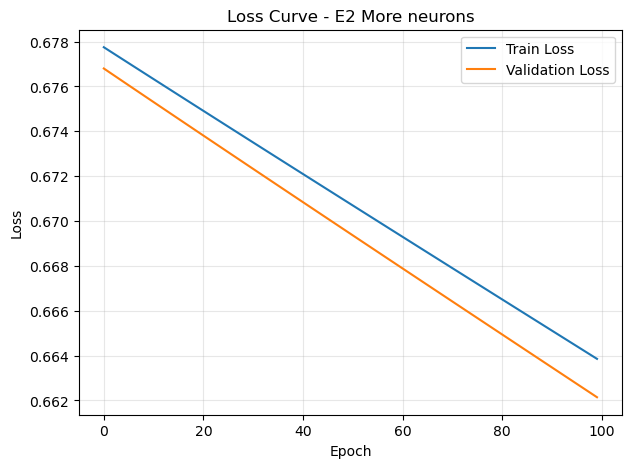

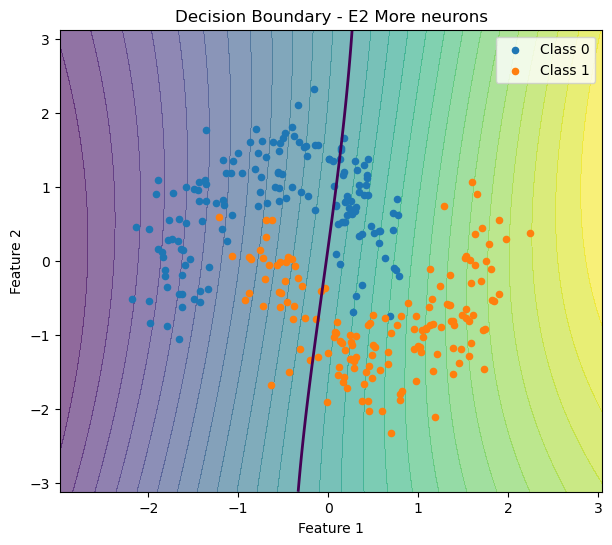


=== #8/8 Experiment ===
Experiment: E1 Baseline
Hidden layers: [2]
Activation: sigmoid
Optimizer: SGD
Learning rate: 0.001
Epochs: 100
Final train loss: 0.6871
Final val loss: 0.6869
Test accuracy: 0.5000


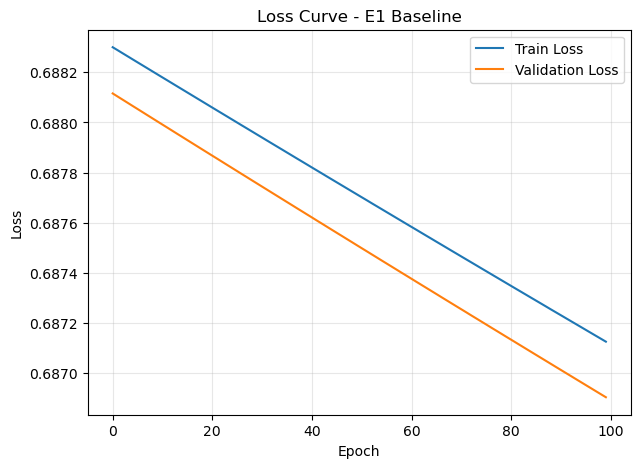

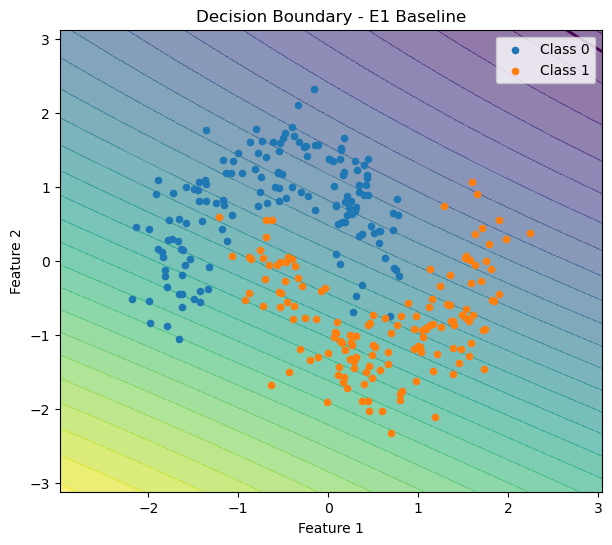

In [ ]:
# =========================================================
# Part III: Experiementing different Hyperparameters (min -> 5 combos!)
# =========================================================

# =========================================================
# 0. Import packages
# =========================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# For accuracy score functions
from sklearn.metrics import accuracy_score



# =========================================================
# 1. Dataset creation
# =========================================================
def prepare_moons_data(n_samples=1000, noise=0.2, test_size=0.3, random_state=42):
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=random_state)

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train).view(-1, 1)
    X_test_t = torch.FloatTensor(X_test)
    y_test_t = torch.FloatTensor(y_test).view(-1, 1)

    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "X_train_t": X_train_t,
        "X_test_t": X_test_t,
        "y_train_t": y_train_t,
        "y_test_t": y_test_t,
        "scaler": scaler
    }


data = prepare_moons_data()


# =========================================================
# 2. Flexible BPNN model
# =========================================================
class FlexibleBPNN(nn.Module):
    def __init__(self, input_dim=2, hidden_layers=[8], activation='relu'):
        super().__init__()

        # Available activation functions
        activation_map = {
            'relu': nn.ReLU,
            'sigmoid': nn.Sigmoid,
        }

        # Error handling for non-supported activation functions
        if activation not in activation_map:
            raise ValueError(f"Unsupported activation: {activation}")

        act_func = activation_map[activation]

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(act_func())
            prev_dim = hidden_dim

        # Final output layer for binary classification
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# =========================================================
# 3. Optimizer helper
# =========================================================
def make_optimizer(model, optimizer_name, lr):
    if optimizer_name == 'SGD':
        return optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'Momentum':
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == 'Adam':
        return optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")


# =========================================================
# 4. Training + evaluation for one experiment
# =========================================================
def run_single_experiment(config, data, seed=42, verbose=False):

    model = FlexibleBPNN(
        input_dim=2,
        hidden_layers=config['hidden_layers'],
        activation=config['activation']
    )

    criterion = nn.BCELoss()
    optimizer = make_optimizer(model, config['optimizer'], config['lr'])

    X_train_t = data["X_train_t"]
    y_train_t = data["y_train_t"]
    X_test_t = data["X_test_t"]
    y_test_t = data["y_test_t"]
    y_test = data["y_test"]

    train_losses = []
    val_losses = []

    epochs = config['epochs']

    for epoch in range(epochs):
        # ----- training -----
        model.train()
        train_outputs = model(X_train_t)
        train_loss = criterion(train_outputs, y_train_t)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        # ----- validation/test loss tracking -----
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_test_t)
            val_loss = criterion(val_outputs, y_test_t)

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

        if verbose and ((epoch + 1) % 10 == 0 or epoch == 0):
            print(
                f"[{config['Experiment']}] "
                f"Epoch {epoch + 1:03d}/{epochs} | "
                f"Train Loss: {train_loss.item():.4f} | "
                f"Val Loss: {val_loss.item():.4f}"
            )

    # ----- final test accuracy -----
    model.eval()
    with torch.no_grad():
        test_probs = model(X_test_t).cpu().numpy().ravel()

    test_preds = (test_probs >= 0.5).astype(int)
    test_accuracy = accuracy_score(y_test, test_preds)

    result = {
        "Experiment": config["Experiment"],
        "hidden_layers": config["hidden_layers"],
        "activation": config["activation"],
        "optimizer": config["optimizer"],
        "lr": config["lr"],
        "epochs": config["epochs"],
        "final_train_loss": train_losses[-1],
        "final_val_loss": val_losses[-1],
        "test_accuracy": test_accuracy,
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "test_probs": test_probs,
        "test_preds": test_preds
    }

    return result


# =========================================================
# 5. Run all experiments and create result table
# =========================================================
def run_experiments(experiments, data, seed=42, verbose=False):
    all_results = []
    full_results = {}

    for config in experiments:
        result = run_single_experiment(config, data, seed=seed, verbose=verbose)
        full_results[config["Experiment"]] = result

        row = {
            "Experiment": result["Experiment"],
            "Hidden layers": str(result["hidden_layers"]),
            "Activation": result["activation"],
            "Optimizer": result["optimizer"],
            "LR": result["lr"],
            "Epochs": result["epochs"],
            "Final train loss": round(result["final_train_loss"], 4),
            "Final val loss": round(result["final_val_loss"], 4),
            "Test accuracy": round(result["test_accuracy"], 4)
        }
        all_results.append(row)

    results_df = pd.DataFrame(all_results)
    results_df = results_df.sort_values(by="Test accuracy", ascending=False).reset_index(drop=True)

    best_experiment_name = results_df.iloc[0]["Experiment"]
    best_result = full_results[best_experiment_name]

    return results_df, full_results, best_result


# =========================================================
# 6. Plotting helpers
# =========================================================
def plot_loss_curve(result, figsize=(7, 5)):
    plt.figure(figsize=figsize)
    plt.plot(result["train_losses"], label="Train Loss")
    plt.plot(result["val_losses"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curve - {result['Experiment']}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_decision_boundary(model, X_data, y_data, title="Decision Boundary", figsize=(7, 6)):
    x_min, x_max = X_data[:, 0].min() - 0.8, X_data[:, 0].max() + 0.8
    y_min, y_max = X_data[:, 1].min() - 0.8, X_data[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_t = torch.FloatTensor(grid)

    model.eval()
    with torch.no_grad():
        zz = model(grid_t).cpu().numpy().reshape(xx.shape)

    plt.figure(figsize=figsize)
    plt.contourf(xx, yy, zz, levels=30, alpha=0.6)
    plt.contour(xx, yy, zz, levels=[0.5], linewidths=2)

    plt.scatter(X_data[y_data == 0, 0], X_data[y_data == 0, 1], s=20, label="Class 0")
    plt.scatter(X_data[y_data == 1, 0], X_data[y_data == 1, 1], s=20, label="Class 1")

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()


# =========================================================
# 7. Example experiment input
#    You can edit this list directly
# =========================================================
experiments = [
    {
        "Experiment": "E1 Baseline",
        "hidden_layers": [2],
        "activation": "sigmoid",
        "optimizer": "SGD",
        "lr": 0.001,
        "epochs": 100
    },
    {
        "Experiment": "E2 More neurons",
        "hidden_layers": [8],
        "activation": "sigmoid",
        "optimizer": "SGD",
        "lr": 0.01,
        "epochs": 100
    },
    {
        "Experiment": "E3 Deeper ReLU",
        "hidden_layers": [8, 8],
        "activation": "relu",
        "optimizer": "SGD",
        "lr": 0.01,
        "epochs": 100
    },
    {
        "Experiment": "E4 Momentum",
        "hidden_layers": [8, 8],
        "activation": "relu",
        "optimizer": "Momentum",
        "lr": 0.01,
        "epochs": 100
    },
    {
        "Experiment": "E5 Adam",
        "hidden_layers": [16, 8],
        "activation": "relu",
        "optimizer": "Adam",
        "lr": 0.01,
        "epochs": 100
    },
    {
        "Experiment": "E6 Adam high LR",
        "hidden_layers": [16, 8],
        "activation": "relu",
        "optimizer": "Adam",
        "lr": 0.02,
        "epochs": 100
    },
    {
        "Experiment": "E6 Adam low LR",
        "hidden_layers": [16, 8],
        "activation": "relu",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs": 100
    },
    {
        "Experiment": "E6 Adam high LR 3 hidden",
        "hidden_layers": [32, 16, 8],
        "activation": "relu",
        "optimizer": "Adam",
        "lr": 0.02,
        "epochs": 100
    }
]


# =========================================================
# 8. Run experiments
# =========================================================
results_df, full_results, best_result = run_experiments(
    experiments=experiments,
    data=data,
    seed=42,
    verbose=False
)


# =========================================================
# 9. Show result table
# =========================================================
print("=== Result Table ===")
print(results_df.to_string(index=False))


# =========================================================
# 10. Show best experiment summary
# =========================================================
print("\n=== Best Experiment ===")
print(f"Experiment: {best_result['Experiment']}")
print(f"Hidden layers: {best_result['hidden_layers']}")
print(f"Activation: {best_result['activation']}")
print(f"Optimizer: {best_result['optimizer']}")
print(f"Learning rate: {best_result['lr']}")
print(f"Epochs: {best_result['epochs']}")
print(f"Final train loss: {best_result['final_train_loss']:.4f}")
print(f"Final val loss: {best_result['final_val_loss']:.4f}")
print(f"Test accuracy: {best_result['test_accuracy']:.4f}")


# =========================================================
# 11. Plot best experiment results
# =========================================================
plot_loss_curve(best_result)

plot_decision_boundary(
    best_result["model"],
    data["X_test"],
    data["y_test"],
    title=f"Decision Boundary - {best_result['Experiment']}"
)


# =========================================================
# 12. Plot other experiments' summary & plot results
# =========================================================

total_experiments = len(results_df)

for rank, (_, row) in enumerate(results_df.iloc[1:].iterrows(), start=2):
    exp_name = row["Experiment"]
    result = full_results[exp_name]

    #Summart
    print(f"\n=== #{rank}/{total_experiments} Experiment ===")
    print(f"Experiment: {result['Experiment']}")
    print(f"Hidden layers: {result['hidden_layers']}")
    print(f"Activation: {result['activation']}")
    print(f"Optimizer: {result['optimizer']}")
    print(f"Learning rate: {result['lr']}")
    print(f"Epochs: {result['epochs']}")
    print(f"Final train loss: {result['final_train_loss']:.4f}")
    print(f"Final val loss: {result['final_val_loss']:.4f}")
    print(f"Test accuracy: {result['test_accuracy']:.4f}")

    #Plots
    plot_loss_curve(result)

    plot_decision_boundary(
        result["model"],
        data["X_test"],
        data["y_test"],
        title=f"Decision Boundary - {exp_name}"
    )

